# Module 00 — Welcome & the mental model

Welcome to the **tsdynamics** hands-on workshop. Over the next modules you'll go from a
raw differential equation to Lyapunov spectra, bifurcation diagrams, basins of attraction,
and a full capstone on grid stability — all with one small, consistent library. This first
notebook is your orientation: get everything running, meet the four objects the whole
library is built around, and take a quick tour of the 154-system catalogue.

`tsdynamics` has one organizing idea: **you write the math, the library does the rest.**
You declare a system symbolically; it lowers to a fast Rust engine and hands you data and
analysis. No compilation step, no warmup, no boilerplate.

**You will learn to:**
- Run the workshop stack (locally or on Colab) and confirm your version.
- Hold the **System → Trajectory → Analysis → Viz** mental model in your head.
- Integrate the Lorenz system and render its attractor in one line.
- Read the anatomy of a `Trajectory` (`.y`, `.t`, `.meta`, named components).
- Tour the catalogue through the registry and iterate a discrete map.
- Run your first chaos quantifier (a Lyapunov spectrum).

*Estimated time: 15 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
try:  # inline figures so plots embed in the notebook (no-op outside IPython)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## 1. The mental model

Every workflow in this library flows through the same four stages. Keep this diagram in
mind and you'll always know which object you're holding and what to do with it next:

```
  System                Trajectory            Analysis (Result)         Viz
 ┌────────────┐        ┌────────────┐        ┌──────────────────┐     ┌──────────┐
 │ the math   │  .integrate()  │ the data   │   ts.lyapunov_    │ typed .value/  │  .plot() │
 │ ẋ = f(x)   │ ─────────────► │ .y  .t     │ ─ spectrum(...) ─► │ .to_dict()/    │ ───────► │  figures │
 │ ts.Lorenz()│  .iterate()    │ .meta      │   ts.correlation_ │ .summary()     │  gifs    │
 └────────────┘                └────────────┘   dimension(...)  └──────────────┘     └──────────┘
```

- **System** — an object that *defines the dynamics* (`ts.Lorenz()`, `ts.Henon()`, or your
  own class in Module 02). It knows the equations, the parameters, and the dimension.
- **Trajectory** — the *data* produced by `.integrate()` (flows) or `.iterate()` (maps):
  arrays of states over time plus provenance metadata.
- **Analysis** — functions that consume a `Trajectory` (or a system, or a bare signal) and
  return **typed Result objects** — a `ScalarResult` behaves like a float but also carries
  `.to_dict()`, `.summary()`, and `.plot()`.
- **Viz** — `.plot()` renders inline; `.to_plot_spec().save(...)` writes files (PNG/PDF/SVG/HTML/GIF).

**Backends** in one sentence: every integration runs on a Rust engine you select with
`backend=` — `"interp"` (the default SSA-tape interpreter), `"jit"` (a Cranelift JIT, fastest
for heavy repeated runs), and `"reference"` (a dependency-light pure-Python oracle) — and they
all agree to numerical tolerance.

## 2. First contact — the Lorenz attractor

Let's make the mental model concrete. Edward Lorenz's 1963 system is the canonical chaotic
flow:

$$\dot x = \sigma(y-x), \qquad \dot y = x(\rho - z) - y, \qquad \dot z = xy - \beta z.$$

We instantiate the **System**, call `.integrate()` to get a **Trajectory**, and hand it to
**Viz** — three lines that span the whole pipeline.

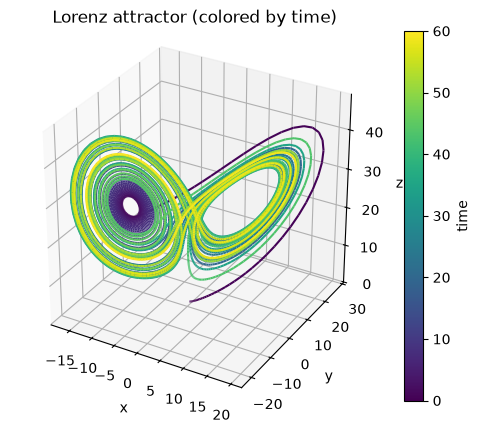

In [2]:
lor = ts.Lorenz()
traj = lor.integrate(final_time=60.0, dt=0.01)     # System -> Trajectory
fig = traj.plot(kind="phase_portrait_3d", components=["x", "y", "z"], color_by="time")
fig.axes[0].set_title("Lorenz attractor (colored by time)")
fig   # a bare Figure as the last expression displays inline

There it is: the famous two-lobed "butterfly." The trajectory never repeats and never
escapes — it winds forever on a strange attractor. Coloring by time shows how the orbit
threads between the two wings. Every attractor picture in this workshop is built exactly
this way: instantiate → integrate → plot.

## 3. Anatomy of a `Trajectory`

A `Trajectory` is not just an array — it is data *plus provenance*. The three attributes you
will use constantly:

- **`traj.y`** — the state array, shape `(n_steps, dim)`.
- **`traj.t`** — the time grid, shape `(n_steps,)`.
- **`traj.meta`** — a dict recording exactly how this run was produced (backend, method, `dt`,
  tolerances, parameters, initial condition, version). Reproducibility comes for free.

In [3]:
print("y shape :", traj.y.shape)      # (n_steps, dim)
print("t shape :", traj.t.shape)
print("t range :", traj.t[0], "->", traj.t[-1])
print("meta keys:", sorted(traj.meta.keys()))
print("backend  :", traj.meta["backend"], "| method:", traj.meta["method"], "| dt:", traj.meta["dt"])
print("params   :", traj.meta["params"])

y shape : (6001, 3)
t shape : (6001,)
t range : 0.0 -> 60.0
meta keys: ['atol', 'backend', 'dt', 'engine', 'family', 'ic', 'method', 'params', 'rtol', 'system', 't0', 'tsdynamics']
backend  : interp | method: rk45 | dt: 0.01
params   : {'sigma': 10.0, 'rho': 28.0, 'beta': 2.6666666666666665}


### Named components vs. column indices

When a system declares a `variables` tuple, you can pull components **by name** — far more
readable than remembering column order. Lorenz declares `("x", "y", "z")`, so `traj["x"]`
works. If a system has **no** `variables`, indexing by name raises `KeyError` and you fall
back to `traj.y[:, i]`. (You'll meet a `variables`-less system, `Duffing`, in Module 01.)

traj['x'] == traj.y[:,0]? True


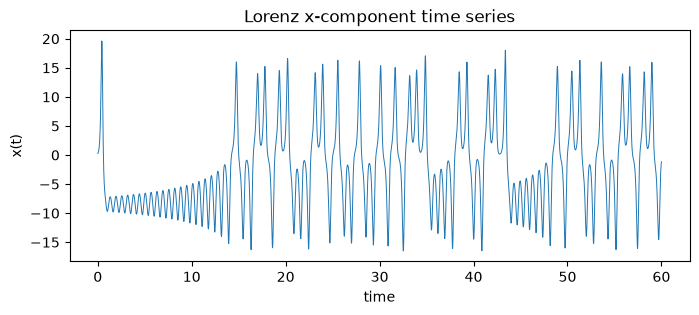

In [4]:
x = traj["x"]            # named component (Lorenz declares variables=("x","y","z"))
z_by_index = traj.y[:, 2]   # the equivalent positional access
print("traj['x'] == traj.y[:,0]?", np.allclose(x, traj.y[:, 0]))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(traj.t, x, lw=0.7)
ax.set_xlabel("time"); ax.set_ylabel("x(t)"); ax.set_title("Lorenz x-component time series")
plt.show()

The `x(t)` trace is aperiodic and irregular — the time-domain signature of chaos. In
Module 05 we'll take a scalar signal like this one and reconstruct the full attractor from
it alone.

## 4. Touring the catalogue via the registry

`tsdynamics` ships **154 built-in systems** across four families. The `registry` is a live
index — every system auto-registers itself, so it always reflects what's installed. Let's
see the headline counts and sample a few names per family.

In [5]:
from tsdynamics import registry

print("families:", registry.families())   # {'ode': 120, 'dde': 5, 'sde': 3, 'map': 26}
for fam in ("ode", "map", "dde", "sde"):
    names = [e.name for e in registry.all_systems(family=fam)][:6]
    print(f"  {fam:>4}: {names}")

families: {'ode': 120, 'dde': 5, 'sde': 3, 'map': 26}
   ode: ['Lorenz', 'LorenzBounded', 'LorenzCoupled', 'Lorenz96', 'Lorenz84', 'Rossler']
   map: ['Henon', 'Ulam', 'Ikeda', 'Tinkerbell', 'Gingerbreadman', 'Zaslavskii']
   dde: ['MackeyGlass', 'IkedaDelay', 'SprottDelay', 'ScrollDelay', 'PiecewiseCircuit']
   sde: ['OrnsteinUhlenbeck', 'GeometricBrownianMotion', 'DoubleWell']


The four families you'll meet across the workshop:

- **ode** (120) — ordinary differential equations: `Lorenz`, `Rossler`, `Thomas`, `Chua`, ...
- **map** (26) — discrete-time maps `x_{n+1} = f(x_n)`: `Henon`, `Logistic`, `Ikeda`, ...
- **dde** (5) — delay differential equations (Module 01): `MackeyGlass`, ...
- **sde** (3) — stochastic differential equations (Module 01): `OrnsteinUhlenbeck`, ...

Any built-in is reachable two ways: `ts.systems.Rossler()` or the lazy shortcut
`ts.Rossler()`. Here's a second chaotic flow — Otto Rössler's 1976 system, a single-scroll
spiral — to show the same three-line pattern with a different attractor.

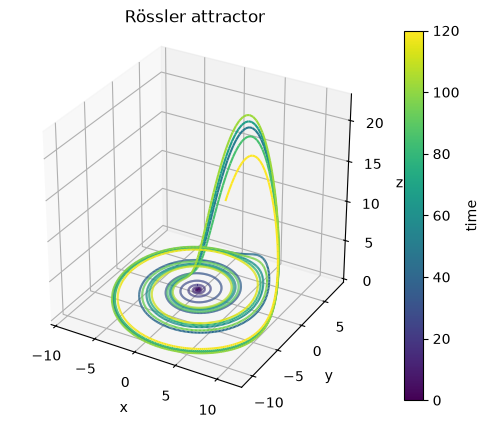

In [6]:
ros_traj = ts.Rossler().integrate(final_time=120.0, dt=0.02)
fig = ros_traj.plot(kind="phase_portrait_3d", components=["x", "y", "z"], color_by="time")
fig.axes[0].set_title("Rössler attractor")
fig

### A discrete map: iterate instead of integrate

Maps don't flow in continuous time — they *iterate*. Same pipeline, different verb: call
`.iterate(steps=...)` instead of `.integrate(...)`. The Hénon map (1976) is a 2-D quadratic
map whose orbit traces a thin fractal curve.

Hénon trajectory shape: (4000, 2)


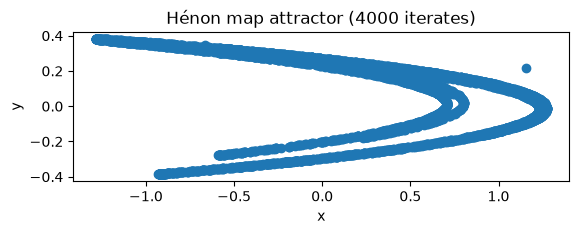

In [7]:
henon = ts.Henon()
hmap = henon.iterate(steps=4000)         # System -> Trajectory (discrete)
print("Hénon trajectory shape:", hmap.y.shape)
fig = hmap.plot(kind="phase_portrait_2d", components=["x", "y"])
fig.axes[0].set_title("Hénon map attractor (4000 iterates)")
fig

Zoom in anywhere on that curve and you'd find it split into more curves, forever — the
hallmark of a fractal attractor. We'll quantify exactly that fractal dimension in Module 05.

## 5. One analysis teaser — the Lyapunov spectrum

The whole point of the **Analysis** stage is turning trajectories into *numbers*. The
headline chaos quantifier is the **Lyapunov spectrum**: the exponential rates at which nearby
trajectories separate along each direction. A positive largest exponent *is* chaos.

For Lorenz the spectrum is famously `[+, 0, −]`: one expanding direction, one neutral
(the flow direction), one strongly contracting. From it, the **Kaplan–Yorke dimension**
estimates the attractor's fractal dimension.

In [8]:
exps = ts.Lorenz().lyapunov_spectrum(final_time=200.0, dt=0.02)
print("Lyapunov spectrum:", np.round(exps, 3))
print("  positive exponent -> chaotic:", exps[0] > 0)

d_ky = ts.kaplan_yorke_dimension(exps)
print("Kaplan-Yorke dimension:", round(float(d_ky), 3))

Lyapunov spectrum: [ 9.1000e-01  7.0000e-03 -1.4583e+01]
  positive exponent -> chaotic: True
Kaplan-Yorke dimension: 2.063


The largest exponent is about `+0.9` (positive → chaos), the middle is essentially zero (the
flow direction), and the last is a large negative number (strong contraction onto the
attractor). The Kaplan–Yorke dimension `≈ 2.06` tells us the Lorenz attractor is a
fractal object that is *just* thicker than a 2-D surface. We devote all of Module 04 to
these ideas — this is your first taste.

## 6. Where this is all heading — the capstone

The workshop culminates in **"Guardian of the Grid"** (Module 09): you'll treat a model
power grid as a nonlinear dynamical system and use *everything* here — trajectories,
bifurcations, Lyapunov exponents, and especially **basins of attraction** — to judge whether
the grid stays synchronized or tips into blackout. Every technique you meet along the way is
a tool you'll reach for there. When you see a foreshadow like *"we'll use basins to judge grid
stability in the capstone,"* that's the thread.

## 🧪 Exercises

Try these before peeking at the solutions below. Each builds directly on a section above.

**Exercise 1 — Plot another 3-D attractor.**
Pick a *different* 3-D chaotic flow from the catalogue and render its phase portrait.
*Hint:* `ts.Rossler` has `variables=("x","y","z")`; try it (or explore the ODE registry with
`registry.all_systems(family="ode")`). Integrate for `final_time≈120`, `dt=0.02`, then
`traj.plot(kind="phase_portrait_3d", components=["x","y","z"])`.

**Exercise 2 — Iterate a map and count its points.**
Instantiate the logistic map `ts.Logistic()`, iterate it for 3000 steps, and print the shape
of `traj.y`. Then plot its time series (`kind="time_series"`) — a 1-D map, so one component.
*Hint:* `ts.Logistic().iterate(steps=3000)`.

**Exercise 3 — Read the provenance.**
Integrate the Lorenz system and print three `meta` fields of your choice (e.g. `"backend"`,
`"method"`, `"ic"`). Then re-run with `backend="jit"` and confirm `meta["backend"]` changed.
*Hint:* `traj.meta` is a dict; `traj.meta["backend"]`.

**Exercise 4 — Quantify a second system.**
Compute the Lyapunov spectrum of the Rössler system (`final_time=200`, `dt=0.02`) and its
Kaplan–Yorke dimension. Is the largest exponent positive?
*Hint:* `ts.Rossler().lyapunov_spectrum(...)`, then `ts.kaplan_yorke_dimension(exps)`.

In [9]:
# Exercise 1 — plot a different 3-D attractor
# YOUR CODE HERE

In [10]:
# Exercise 2 — iterate the logistic map, print shape, plot time series
# YOUR CODE HERE

In [11]:
# Exercise 3 — read meta fields; compare interp vs jit backend
# YOUR CODE HERE

In [12]:
# Exercise 4 — Lyapunov spectrum + Kaplan-Yorke dimension of Rössler
# YOUR CODE HERE

## ✅ Solutions

### Solution 1
The Rössler system is a natural pick — it declares named components so plotting is clean.

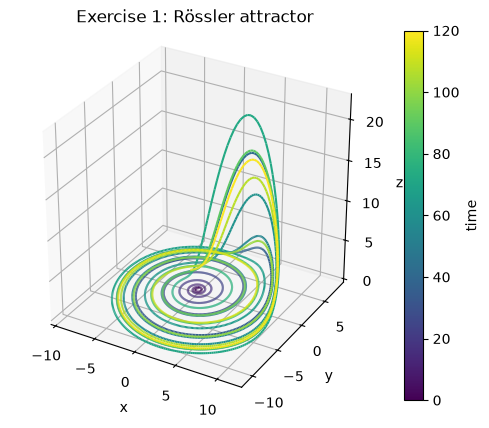

In [13]:
sol1 = ts.Rossler().integrate(final_time=120.0, dt=0.02)
fig = sol1.plot(kind="phase_portrait_3d", components=["x", "y", "z"], color_by="time")
fig.axes[0].set_title("Exercise 1: Rössler attractor")
fig

### Solution 2
The logistic map is 1-D, so `traj.y` has shape `(steps, 1)` and its natural view is a time
series (or a cobweb — more on maps in Modules 01 and 03).

Logistic trajectory shape: (3000, 1)


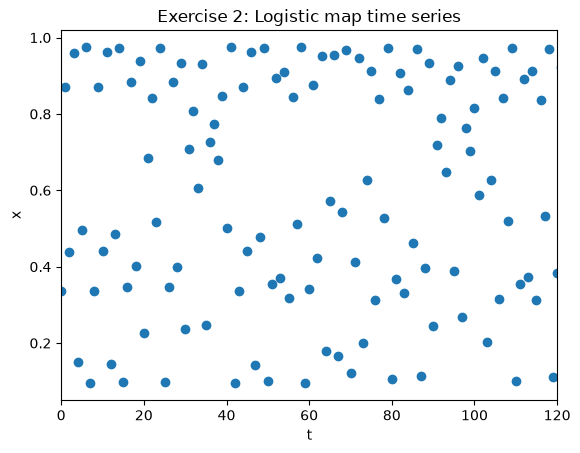

In [14]:
log_traj = ts.Logistic().iterate(steps=3000)
print("Logistic trajectory shape:", log_traj.y.shape)   # (3000, 1)
fig = log_traj.plot(kind="time_series")
fig.axes[0].set_title("Exercise 2: Logistic map time series")
fig.axes[0].set_xlim(0, 120)   # zoom in so the structure is visible
fig

### Solution 3
`meta` is the reproducibility record. Switching the backend is one keyword — starting both runs
from the *same* initial condition, `interp` and `jit` produce **bit-for-bit identical** output
(they lower to the same tape); only the engine that executes it differs.

In [15]:
ic = [1.0, 1.0, 1.0]   # the SAME fixed start for both, so only the engine differs
sol3a = ts.Lorenz().integrate(final_time=20.0, dt=0.01, ic=ic)                 # default interp
sol3b = ts.Lorenz().integrate(final_time=20.0, dt=0.01, ic=ic, backend="jit")  # Cranelift JIT
print("interp backend:", sol3a.meta["backend"], "| method:", sol3a.meta["method"])
print("jit    backend:", sol3b.meta["backend"], "| method:", sol3b.meta["method"])
print("initial condition:", np.round(sol3a.meta["ic"], 4))
print("bit-for-bit identical?", np.array_equal(sol3a.y, sol3b.y))
print("max abs difference   :", np.max(np.abs(sol3a.y - sol3b.y)))

interp backend: interp | method: rk45
jit    backend: jit | method: rk45
initial condition: [1. 1. 1.]
bit-for-bit identical? True
max abs difference   : 0.0


### Solution 4
Rössler is also chaotic — one positive exponent — but its Kaplan–Yorke dimension sits just
above 2, like Lorenz.

In [16]:
ros_exps = ts.Rossler().lyapunov_spectrum(final_time=200.0, dt=0.02)
print("Rössler spectrum:", np.round(ros_exps, 4))
print("largest exponent positive (chaotic)?", ros_exps[0] > 0)
print("Kaplan-Yorke dimension:", round(float(ts.kaplan_yorke_dimension(ros_exps)), 3))

Rössler spectrum: [ 0.067  -0.01   -5.4106]
largest exponent positive (chaotic)? True
Kaplan-Yorke dimension: 2.011


## Recap / Where next

You now have the whole library in one picture:

**System → Trajectory → Analysis (Result) → Viz.**

You integrated a flow, iterated a map, read a trajectory's data and provenance, toured the
154-system catalogue through the registry, and ran your first Lyapunov spectrum. Everything
that follows is a deeper cut of one of these four stages.

**Next up — Module 01 (`01_integration`):** the full integration toolkit — `method`/`backend`
choices, stiff solvers, events, the stepping protocol, and all four families (ODE, map, DDE,
SDE) in one place. See you there.